Saved: /home/hmf/work/FA_test/plots/must_radec_box10_09_10500.pdf


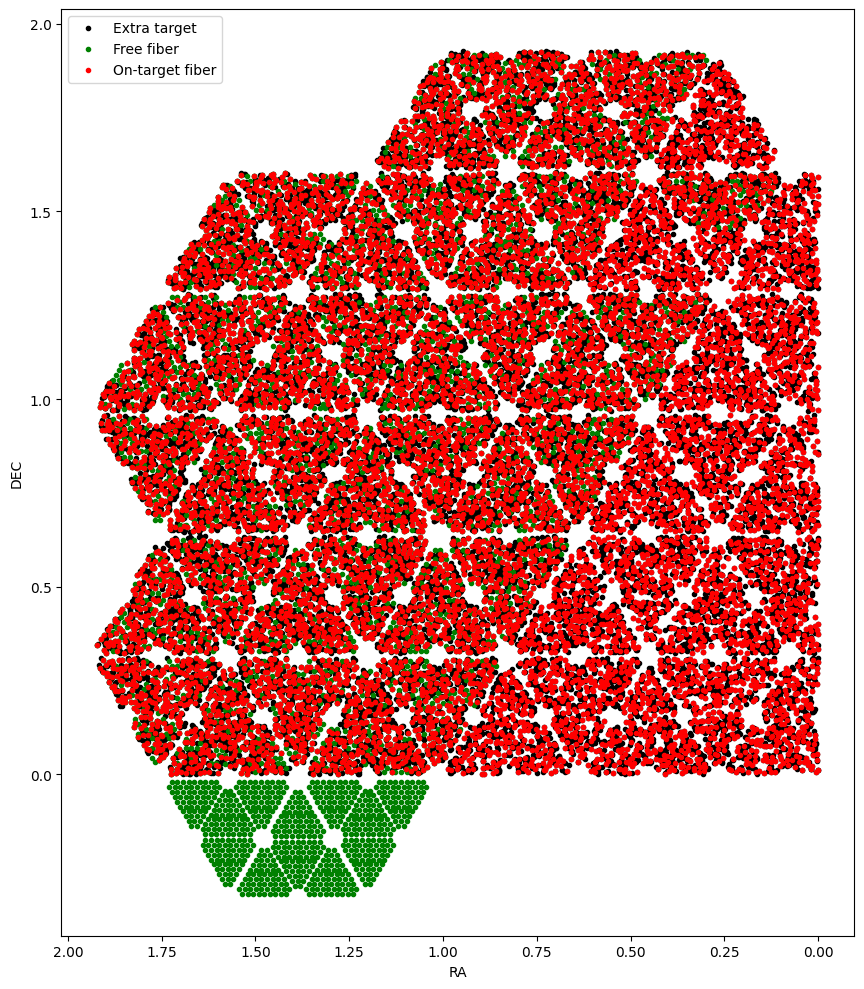

In [3]:
'''
Investigate fiberassign outputs
'''
import sys
sys.path.append('/home/hmf/work/software/must_fbautil-main/')
from python.utils import *
import astropy.io.fits as fits  
#Investigate example outputs from https://github.com/forero/SandboxDESI
sandbox_path = '/home/dong/disk/must/repos/desi/SandboxDESI/fba_output/'

def plot_example():
    '''
    Investigate example outputs from https://github.com/forero/SandboxDESI
    '''
    targets = fits.open(sandbox_path + 'inputs/targets.fits')
    sky = fits.open(sandbox_path + 'inputs/sky.fits')
    tiles = fits.open(sandbox_path + 'inputs/tiles_subset.fits')
    out = fits.open(sandbox_path + 'outputs/fba-005881.fits')
    outm = fits.opoen(sandbox_path + 'outputs_merged/fiberassign-005881.fits')
    
    ra_tar = targets[1].data['RA']
    dec_tar = targets[1].data['DEC']
    ra_sky = sky[1].data['RA']
    dec_sky = sky[1].data['DEC']
    
    for i in range(1, len(out)): print(i, out[i].data.dtype)
    for i in range(1, len(outm)): print(i, outm[i].data.dtype)
    for i in range(1, len(out)): print(len(out[i].data), end=',')
    for i in range(1, len(outm)): print(len(outm[i].data), end=',')
    
    
    plt.plot(ra_tar, dec_tar, 'ro', ms=10) # targets coords
    plt.plot(ra_sky, dec_sky, 'bo', ms=10) # sky coords
    
    plt.plot(out[1].data['TARGET_RA'], out[1].data['TARGET_DEC'], 'go') # all fibers coords
    plt.plot(out[2].data['TARGET_RA'], out[2].data['TARGET_DEC'], 'k.') # (targets + sky) intersect (all fibers)
    plt.pause(0.1)
    
    plt.figure()
    plt.plot(outm[1].data['TARGET_RA'], outm[1].data['TARGET_DEC'], 'go') # almost all fibers coords
    plt.plot(outm[2].data['TARGET_RA'], outm[2].data['TARGET_DEC'], 'yo') # 20 fibers at plate edge, 2 per petal
    
    plt.plot(outm[3].data['RA'], outm[3].data['DEC'], 'k.')
    
    plt.plot(outm[5].data['TARGET_RA'], outm[5].data['TARGET_DEC'], 'go') # all fibers coords
    plt.plot(outm[6].data['TARGET_RA'], outm[6].data['TARGET_DEC'], 'k.') # (targets + sky) intersect (all fibers)
    
    plt.pause(0.1)

def print_example_qa():
    '''
    Investigate example qa outputs from https://github.com/forero/SandboxDESI
    '''
    qa = json.loads(open(sandbox_path + 'outputs/qa.json').read())
    qam = json.loads(open(sandbox_path + 'outputs_merged/qa.json').read())
    for key in qa['5881'].keys():
        print(key, type(qa['5881'][key]), end=': ')
        if type(qa['5881'][key]) is not list: print(qa['5881'][key])
        else: print('')
    for key in qam['5881'].keys():
        print(key, type(qam['5881'][key]), end=': ')
        if type(qam['5881'][key]) is not list: print(qam['5881'][key])
        else: print('')

def targetid2radec(targetid, targets):
    '''
    Get RA and Dec given TARGETID
    Inputs
        targetid (array-like): list of TARGETIDs
        targets (astropy.io.fits.hdu.hdulist.HDUList): the opened targets table fits file
    Returns
        ras, decs (array): the RA and Dec for targets in targetid
    '''
    ras = np.array([targets[1].data['RA'][tid==targets[1].data['TARGETID']] for tid in targetid]).flatten()
    decs = np.array([targets[1].data['DEC'][tid==targets[1].data['TARGETID']] for tid in targetid]).flatten()
    return ras, decs

def plot_output_radec(output_file, target_file, tosave=None):
    '''
    Plot fiberassign output. RA Dec of available and assigned targets, free fibers
    Inputs
        output_file (str): name of the fiberassign output file
        target_file (str): name of the fiberassign input targets file
        tosave (str): the name of the figure file to generate
    Outputs
        figure file of the plot
    '''
    outputs = fits.open(output_file)
    # ra/decs for available
    targets = fits.open(target_file)
    ras, decs = targetid2radec(outputs['FAVAIL'].data['TARGETID'], targets)
    # add ra/dec to outputs available targets
    avail = Table(outputs['FAVAIL'].data)
    avail.add_column(ras.flatten(), name="RA")
    avail.add_column(decs.flatten(), name="DEC")
    outputs['FAVAIL'] = fits.BinTableHDU(avail)
    outputs[3].name = 'FAVAIL'
    
    # PLATE_RA/DEC == TARGET_RA/DEC
    plate_ra= outputs['FASSIGN'].data['PLATE_RA']
    plate_ra[plate_ra >180] = (plate_ra[plate_ra >180] + 180) % 360 - 180
    plate_dec = outputs['FASSIGN'].data['PLATE_DEC']
    assigned_ra = outputs['FTARGETS'].data['TARGET_RA']
    assigned_ra[assigned_ra >180] = (assigned_ra[assigned_ra >180] + 180) % 360 - 180
    assigned_dec = outputs['FTARGETS'].data['TARGET_DEC']
    avail_ra = outputs['FAVAIL'].data['RA']
    avail_dec = outputs['FAVAIL'].data['DEC']
    
    # plot
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.plot(avail_ra, avail_dec, 'k.', label='Extra target')
    ax.plot(plate_ra[0:10000], plate_dec[0:10000], 'g.', label='Free fiber')
    ax.plot(assigned_ra, assigned_dec, 'r.', label='On-target fiber')
    plotconfig_radec(ax)
    ax.legend()
    save_plot(fig, tosave)
    plt.show()


if __name__=='__main__':
    '''
    Plot fiberassign output. RA Dec of available and assigned targets, free fibers
    '''
    path = '/home/hmf/work/FA_test/'
    plot_random = True
    if plot_random:
        output_file = path + '/output/tiles_box10_1visit_1%07d.fits'%(1)
        target_file = path + '/data/random/targets_exdense_box10_09_10500.fits'
        tosave = path + 'plots/must_radec_box10_09_10500.pdf'
        #tosave = None
        plot_output_radec(output_file, target_file, tosave)
